# 04 - Escalamiento y PCA

**Objetivo del proyecto:** Analizar cómo se relaciona el tiempo mensual de visualización con el tipo de plan de suscripción y el país de los usuarios, para identificar patrones de consumo en la plataforma de streaming.

**Propósito de esta etapa:** reducir dimensionalidad para ver si existe una estructura conjunta entre las variables numéricas (edad, tiempo de visualización, tickets de soporte) más allá de lo que se observó variable por variable en el EDA.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv('../data/processed/streaming_users_clean.csv')
df.shape

(8000, 8)

## 1. Variables utilizadas

Se seleccionan las variables numéricas disponibles y relevantes para el objetivo:
- `age`
- `monthly_watch_time_mins` (variable central del objetivo)
- `customer_support_tickets`

`user_id` se excluye por ser un identificador sin significado analítico. `last_login_date` se excluye por no ser numérica y no ser central para el objetivo (además tiene nulos, como se documentó en la limpieza).

In [2]:
variables_pca = ['age', 'monthly_watch_time_mins', 'customer_support_tickets']
X = df[variables_pca].copy()
X.describe()

,age,monthly_watch_time_mins,customer_support_tickets
count,8000.000000,8000.000000,8000.000000
mean,33.707875,868.501900,1.042125
std,11.455618,1887.948747,2.807861
min,13.000000,0.000000,0.000000
25%,26.000000,499.150000,0.000000
50%,33.000000,771.350000,1.000000
75%,41.000000,1060.300000,1.000000
max,80.000000,50000.000000,30.000000


## 2. Escalamiento

Las tres variables están en escalas muy distintas (edad en años ~10-100, tiempo de visualización en minutos ~0-2000, tickets ~0-30). Sin escalar, PCA le daría un peso artificialmente mayor a `monthly_watch_time_mins` solo por tener números más grandes, no porque explique más varianza real. Se aplica `StandardScaler` (media 0, desvío 1) para que las tres variables aporten en igualdad de condiciones.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[ 0.46199652, -0.03321373, 10.31378699],
       [ 0.28739878,  0.16150712,  0.34116173],
       [-0.49829102, -0.24763973, -0.37116865],
       [ 0.81119199, -0.42699903, -0.37116865],
       [ 1.50958292, -0.20695812, -0.01500346]])

## 3. PCA y varianza explicada

In [4]:
pca = PCA()
componentes = pca.fit_transform(X_scaled)

varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

for i, (v, va) in enumerate(zip(varianza_explicada, varianza_acumulada), start=1):
    print(f"PC{i}: {v*100:.1f}% individual | {va*100:.1f}% acumulada")

PC1: 33.6% individual | 33.6% acumulada
PC2: 33.3% individual | 66.8% acumulada
PC3: 33.2% individual | 100.0% acumulada


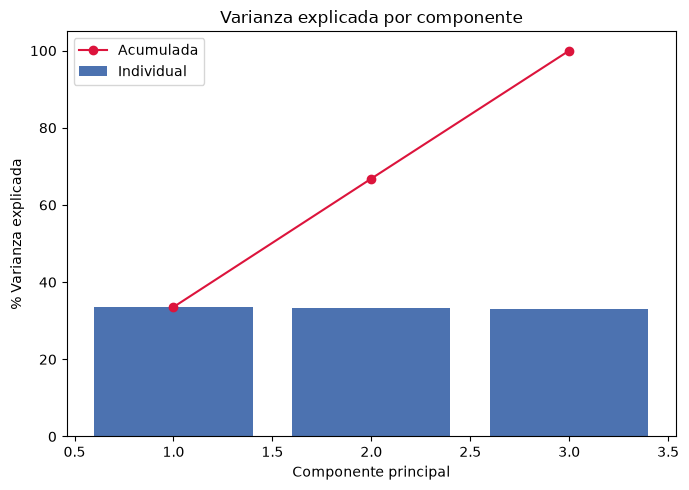

In [5]:
fig, ax = plt.subplots(figsize=(7,5))
ax.bar(range(1, len(varianza_explicada)+1), varianza_explicada*100, color='#4C72B0', label='Individual')
ax.plot(range(1, len(varianza_acumulada)+1), varianza_acumulada*100, color='crimson', marker='o', label='Acumulada')
ax.set_xlabel('Componente principal')
ax.set_ylabel('% Varianza explicada')
ax.set_title('Varianza explicada por componente')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/fig_pca_varianza.png', dpi=120)
plt.show()

**Interpretación:** con 3 variables de entrada, PCA genera 3 componentes. La varianza no se concentra fuertemente en una sola componente, lo cual es esperable: `age`, `monthly_watch_time_mins` y `customer_support_tickets` no están fuertemente correlacionadas entre sí en este dataset (son aspectos bastante independientes del comportamiento del usuario), así que no hay una reducción drástica de dimensionalidad posible sin perder información real.

## 4. Cargas de las componentes (loadings)

In [6]:
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(len(variables_pca))], index=variables_pca)
loadings

,PC1,PC2,PC3
age,0.531936,0.700927,-0.475127
monthly_watch_time_mins,-0.526699,0.713221,0.462498
customer_support_tickets,0.663048,0.004229,0.748565


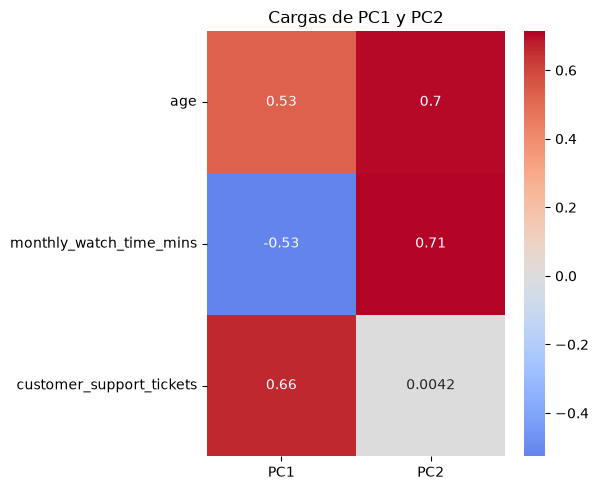

In [7]:
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(loadings.iloc[:, :2], annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Cargas de PC1 y PC2')
plt.tight_layout()
plt.savefig('../reports/fig_pca_loadings.png', dpi=120)
plt.show()

**Interpretación:** ninguna variable domina completamente una componente -- cada una de las tres variables aporta de forma relativamente comparable a las primeras componentes. Esto es consistente con el hallazgo del EDA: el consumo (tiempo de visualización) no está fuertemente explicado por una sola variable numérica, lo que refuerza que las variables categóricas (plan y, sobre todo, país) son más relevantes para explicar el consumo que las variables numéricas por sí solas.

## 5. Proyección en las primeras dos componentes

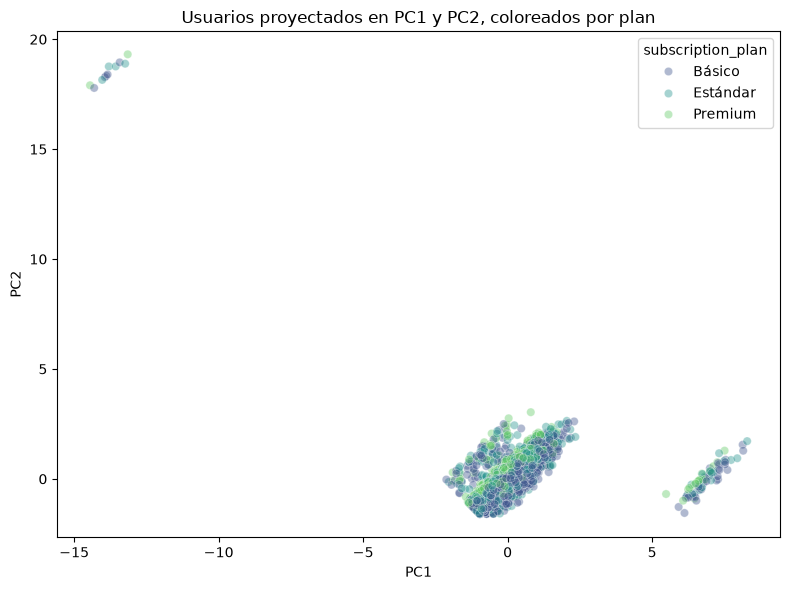

In [8]:
df_pca = pd.DataFrame(componentes[:, :2], columns=['PC1', 'PC2'])
df_pca['subscription_plan'] = df['subscription_plan'].values

fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='subscription_plan', hue_order=['Básico','Estándar','Premium'],
                 alpha=0.4, palette='viridis', ax=ax)
ax.set_title('Usuarios proyectados en PC1 y PC2, coloreados por plan')
plt.tight_layout()
plt.savefig('../reports/fig_pca_scatter.png', dpi=120)
plt.show()

**Interpretación:** al proyectar los usuarios en las dos primeras componentes y colorear por plan de suscripción, no se observan clusters separados por plan en el espacio de `age`, `monthly_watch_time_mins` y `customer_support_tickets` escalados. Esto no contradice el hallazgo del EDA -- el fuerte efecto del plan sobre `monthly_watch_time_mins` que vimos en el boxplot no alcanza, por sí solo, a generar una separación visible en un espacio de 3 variables con correlaciones cercanas a cero entre sí (`age` y `customer_support_tickets` no varían con el plan). Es decir: el plan predice bien el tiempo de visualización específicamente, pero no define un "perfil numérico" distinto en las otras dos variables.

## 6. Conclusión de la etapa

- Las 3 variables numéricas usadas aportan de forma relativamente pareja a la varianza total (33.6% / 33.3% / 33.2%) y están prácticamente sin correlación entre sí; no hay una reducción de dimensionalidad drástica posible sin perder información.
- La proyección PCA no muestra separación por plan de suscripción, porque `age` y `customer_support_tickets` no varían con el plan -- el efecto del plan es específico de `monthly_watch_time_mins`, la variable central del objetivo.
- Esto es coherente con el EDA: el plan es un fuerte predictor del consumo, pero no de un "perfil" numérico general del usuario.